In [83]:
# Cell 1: Imports
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import pickle

In [84]:
#import the label encoder from the Models directory and load the preprocessed data from the processed directory 
with open('../Models/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

with open('../data/processed/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)



In [85]:
X_test=data['X_test']
y_test=data['y_test']
X_train=data['X_train']
y_train=data['y_train']

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [86]:
X_test_flat.shape

(44, 220)

In [87]:
#import the XGBoost model from the Models directory
with open('../Models/xgboost_model.pkl', 'rb') as f:
    final_model = pickle.load(f)

In [88]:
# Cell 2: Predictions and Accuracy
y_pred = final_model.predict(X_test_flat)
accuracy = accuracy_score(y_test, y_pred)

print(f"Final Model Test Accuracy: {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Final Model Test Accuracy: 95.45%

Classification Report:
              precision    recall  f1-score   support

       achen       1.00      1.00      1.00         4
        achi       0.80      1.00      0.89         4
         ami       1.00      1.00      1.00         4
       apnar       1.00      0.75      0.86         4
        apni       1.00      1.00      1.00         4
   dhonnobad       1.00      1.00      1.00         4
       kemon       1.00      0.75      0.86         4
         kii       1.00      1.00      1.00         4
        naam       1.00      1.00      1.00         4
       salam       1.00      1.00      1.00         4
        valo       0.80      1.00      0.89         4

    accuracy                           0.95        44
   macro avg       0.96      0.95      0.95        44
weighted avg       0.96      0.95      0.95        44



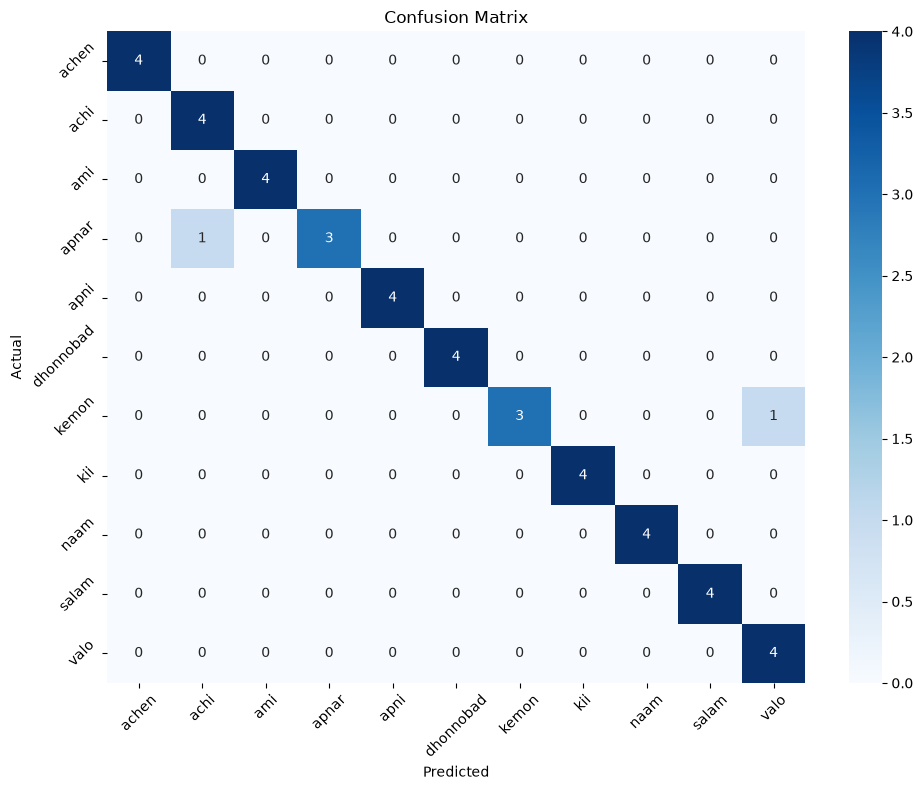

In [89]:
# Cell 3: Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()


Top 10 Most Important Features:
         feature  importance
58      t5_flex4    0.027194
181  t16_accel_x    0.025467
133    t12_flex2    0.019453
112    t10_flex3    0.016765
102     t9_flex4    0.015837
211    t19_flex3    0.015028
122    t11_flex2    0.014745
159  t14_accel_x    0.013950
135    t12_flex4    0.013807
111    t10_flex2    0.013286


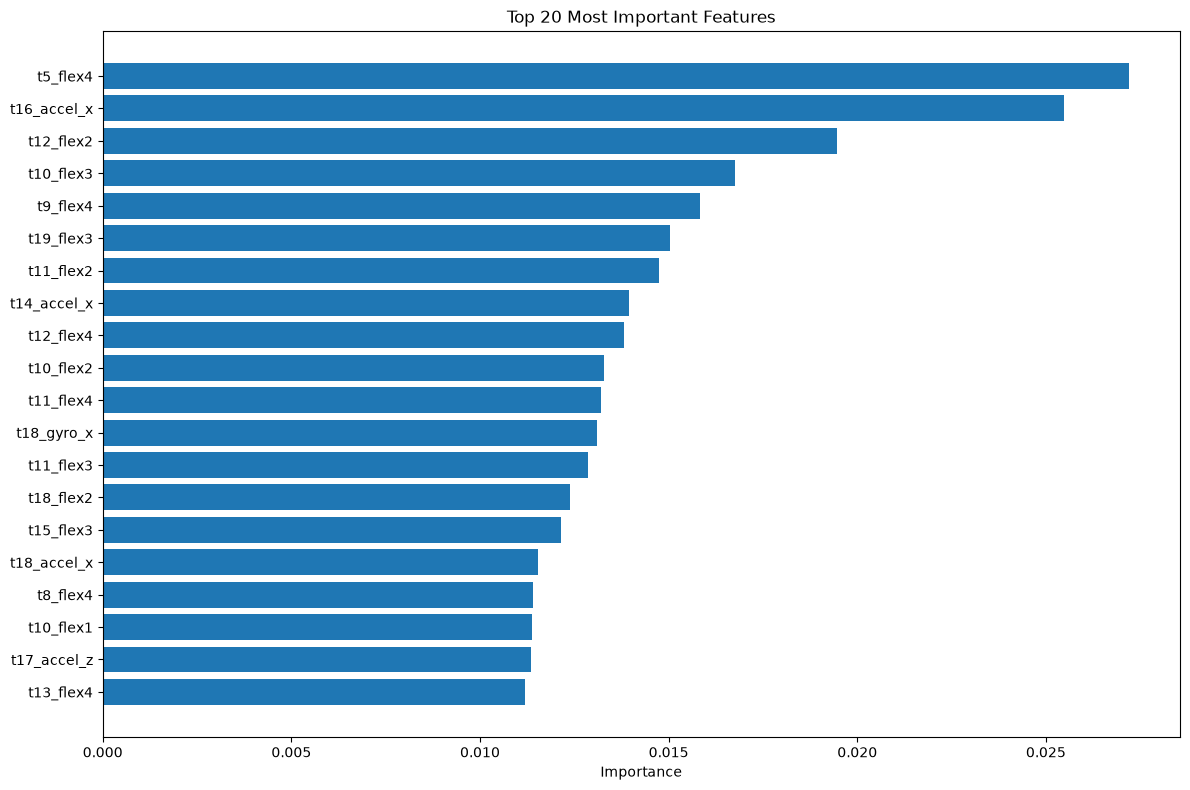

In [90]:
# Cell 4: Feature Importance
importance = final_model.feature_importances_
sensor_names = ['flex1', 'flex2', 'flex3', 'flex4', 'flex5', 
                'accel_x', 'accel_y', 'accel_z', 
                'gyro_x', 'gyro_y', 'gyro_z']

feature_names = [f't{t}_{sensor}' for t in range(20) for sensor in sensor_names]

importance_df = pd.DataFrame({
    'feature': feature_names[:len(importance)],
    'importance': importance
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(importance_df.head(10))

# Plot
plt.figure(figsize=(12, 8))
top_features = importance_df.head(20)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.title('Top 20 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()